In [ ]:
!pip install kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"blossomspine","key":"9ab6979c60c7e62d7a3b8d19a212f189"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
 60% 117M/195M [00:00<00:00, 1.22GB/s]
100% 195M/195M [00:00<00:00, 796MB/s] 


In [ ]:
import os
import shutil

DATASET_PATH = "/content/data/Dataset_BUSI_with_GT"
OUTPUT_PATH = "/content/data/Dataset_BUSI_with_GT/train"

classes = ["benign", "malignant", "normal"]

os.makedirs(OUTPUT_PATH, exist_ok=True)

for cls in classes:
    src_folder = os.path.join(DATASET_PATH, cls)
    dst_folder = os.path.join(OUTPUT_PATH, cls.replace(" ", "_"))
    os.makedirs(dst_folder, exist_ok=True)

    # Only include image files, exclude mask files
    images = [
        f for f in os.listdir(src_folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png')) and "_mask" not in f.lower()
    ]

    for img in images:
        src_path = os.path.join(src_folder, img)
        dst_path = os.path.join(dst_folder, img)

        # Copy image
        shutil.copy2(src_path, dst_path)

    print(f"Class {cls}: {len(images)} images copied (without masks).")

print("All class images copied into train folder (mask images removed).")

Class benign: 437 images copied (without masks).
Class malignant: 210 images copied (without masks).
Class normal: 133 images copied (without masks).
All class images copied into train folder (mask images removed).


In [ ]:
train_dir = "/content/data/Dataset_BUSI_with_GT/train"

# **Oversampling and Label Encoding**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import numpy as np
import os

# Data augmentation settings
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

target_count = 450  # max images per class

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    current_count = len(images)

    if current_count >= target_count:
        print(f"Skipping {cls}: {current_count} images already present.")
        continue

    needed = target_count - current_count
    print(f"Augmenting {cls}: generating {needed} images...")

    img_index = 0
    for _ in range(needed):
        img_path = os.path.join(cls_path, images[img_index % len(images)])
        img = np.expand_dims(np.array(Image.open(img_path).convert("RGB")), axis=0)
        aug_iter = datagen.flow(img, batch_size=1, save_to_dir=cls_path, save_prefix="aug", save_format="jpg")
        next(aug_iter)
        img_index += 1

print("✅ Data augmentation completed.\n")

# Print final class counts
for cls in os.listdir(train_dir):
    count = len(os.listdir(os.path.join(train_dir, cls)))
    print(f"{cls}: {count} images")

Augmenting malignant: generating 4 images...
Augmenting benign: generating 1 images...
Augmenting normal: generating 3 images...
✅ Data augmentation completed.

malignant: 450 images
benign: 450 images
normal: 450 images


In [ ]:
from sklearn.preprocessing import LabelEncoder
import os
import pandas as pd

# Count images per class
df = pd.DataFrame([(cls, len(os.listdir(os.path.join(train_dir, cls))))
                   for cls in os.listdir(train_dir)], columns=["label", "count"])

encoder = LabelEncoder()
df["Label_num"] = encoder.fit_transform(df["label"])

image_paths = []
labels_num = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        image_paths.append(os.path.join(cls_path, img_name))
        labels_num.append(encoder.transform([cls])[0])

df_balanced = pd.DataFrame({"image_path": image_paths, "label_num": labels_num})

print("Class counts after augmentation:")
print(df_balanced["label_num"].value_counts())

Class counts after augmentation:
label_num
1    450
0    450
2    450
Name: count, dtype: int64


# **Train-Test-Split**

In [ ]:
from sklearn.model_selection import train_test_split

df_balanced['label_num'] = df_balanced['label_num'].astype(str)

train_df, temp_df = train_test_split(df_balanced, train_size=0.8, shuffle=True,
                                     stratify=df_balanced['label_num'], random_state=42)

valid_df, test_df = train_test_split(temp_df, test_size=0.5, shuffle=True,
                                     stratify=temp_df['label_num'], random_state=42)

print("Train size:", train_df.shape)
print("Validation size:", valid_df.shape)
print("Test size:", test_df.shape)

Train size: (1080, 2)
Validation size: (135, 2)
Test size: (135, 2)


# Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input


batch_size = 32
img_size = (224, 224)

tr_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)


train_gen = tr_gen.flow_from_dataframe(train_df, x_col='image_path', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='image_path', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size)

test_gen = ts_gen.flow_from_dataframe(test_df, x_col='image_path', y_col='label_num',
                                      target_size=img_size, class_mode='sparse',
                                      color_mode='rgb', shuffle=False, batch_size=batch_size)


Found 1080 validated image filenames belonging to 3 classes.
Found 135 validated image filenames belonging to 3 classes.
Found 135 validated image filenames belonging to 3 classes.


# Create Spatial Attetion **EfficientNetB0** Model , Train Model, Plot Accuracy & Loss, Evaluate on Test Set

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, Conv2D, Multiply, Concatenate, Lambda
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

# Spatial Attention Block (CBAM-style)
def spatial_attention(input_tensor):
    # Average pooling across channels
    avg_pool = Lambda(lambda x: K.mean(x, axis=-1, keepdims=True))(input_tensor)
    # Max pooling across channels
    max_pool = Lambda(lambda x: K.max(x, axis=-1, keepdims=True))(input_tensor)
    # Concatenate along channel axis
    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    # Convolution + sigmoid activation
    attention = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    # Multiply attention with input
    return Multiply()([input_tensor, attention])

# EfficientNet with Spatial Attention
def create_efficientnet_spatial(input_shape=(224,224,3), num_classes=3):
    inputs = Input(shape=input_shape)
    base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=inputs)

    # Freeze most layers (fine-tune last 10)
    for layer in base.layers[:-10]:
        layer.trainable = False

    x = base.output

    # Apply Spatial Attention
    x = spatial_attention(x)

    # Global pooling and dense layers
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

# Create and compile the model
model = create_efficientnet_spatial(num_classes=3)
model.compile(optimizer=Adam(0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Show summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,839,689 (18.46 MB)

 Trainable params: 1,682,326 (6.42 MB)

 Non-trainable params: 3,157,363 (12.04 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint , ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,
    callbacks= callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4070 - loss: 1.4418
Epoch 1: val_accuracy improved from -inf to 0.52593, saving model to best_model.h5


34/34 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.4085 - loss: 1.4381 - val_accuracy: 0.5259 - val_loss: 0.9940 - learning_rate: 1.0000e-04
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6065 - loss: 0.9803
Epoch 2: val_accuracy improved from 0.52593 to 0.61481, saving model to best_model.h5


34/34 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.6065 - loss: 0.9796 - val_accuracy: 0.6148 - val_loss: 0.9243 - learning_rate: 1.0000e-04
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6719 - loss: 0.8148
Epoch 3: val_accuracy improved from 0.61481 to 0.66667, saving model to best_model.h5


34/34 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.6719 - loss: 0.8150 - val_accuracy: 0.6667 - val_loss: 0.8756 - learning_rate: 1.0000e-04
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7165 - loss: 0.6800
Epoch 4: val_accuracy improved from 0.66667 to 0.71111, saving model to best_model.h5


...

34/34 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.7892 - loss: 0.5561 - val_accuracy: 0.7778 - val_loss: 0.5676 - learning_rate: 1.0000e-04
Epoch 10/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7977 - loss: 0.5244
Epoch 10: val_accuracy improved from 0.77778 to 0.80741, saving model to best_model.h5


34/34 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.7974 - loss: 0.5248 - val_accuracy: 0.8074 - val_loss: 0.5275 - learning_rate: 1.0000e-04
Epoch 11/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7983 - loss: 0.5159
Epoch 11: val_accuracy did not improve from 0.80741
34/34 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.7988 - loss: 0.5149 - val_accuracy: 0.7852 - val_loss: 0.5073 - learning_rate: 1.0000e-04
Epoch 12/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8344 - loss: 0.4810
Epoch 12: val_accuracy did not improve from 0.80741
34/34 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.8343 - loss: 0.4803 - val_accuracy: 0.7852 - val_loss: 0.5179 - learning_rate: 1.0000e-04
Epoch 13/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8311 - loss: 0.4500
Epoch 13: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 13: val_accuracy did not improve from 0.80741
34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.8312 - loss: 0.4495 - val_accur

34/34 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.8345 - loss: 0.4075 - val_accuracy: 0.8148 - val_loss: 0.4621 - learning_rate: 5.0000e-05
Epoch 17/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8243 - loss: 0.4027
Epoch 17: val_accuracy improved from 0.81481 to 0.82222, saving model to best_model.h5


34/34 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.8243 - loss: 0.4033 - val_accuracy: 0.8222 - val_loss: 0.4409 - learning_rate: 5.0000e-05
Epoch 18/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8782 - loss: 0.3338
Epoch 18: val_accuracy did not improve from 0.82222
34/34 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.8776 - loss: 0.3349 - val_accuracy: 0.8222 - val_loss: 0.4369 - learning_rate: 5.0000e-05
Epoch 19/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8469 - loss: 0.3815
Epoch 19: val_accuracy improved from 0.82222 to 0.83704, saving model to best_model.h5


34/34 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.8471 - loss: 0.3811 - val_accuracy: 0.8370 - val_loss: 0.4292 - learning_rate: 5.0000e-05
Epoch 20/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8682 - loss: 0.3701
Epoch 20: val_accuracy did not improve from 0.83704
34/34 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.8678 - loss: 0.3701 - val_accuracy: 0.8222 - val_loss: 0.4147 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 19.


In [ ]:
loss, accuracy = model.evaluate(test_gen, verbose=1)

print(f"Final Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8698 - loss: 0.3220
Final Test Accuracy: 85.93%
Final Test Loss: 0.3642


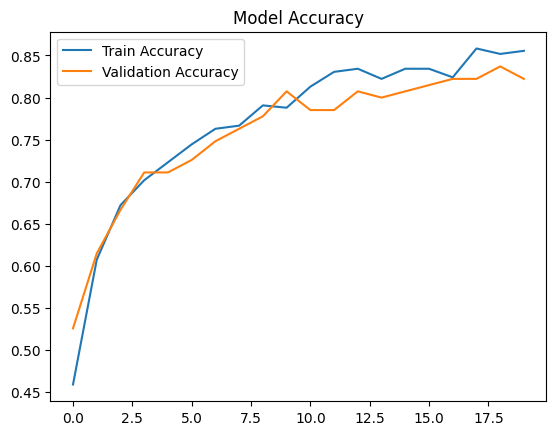

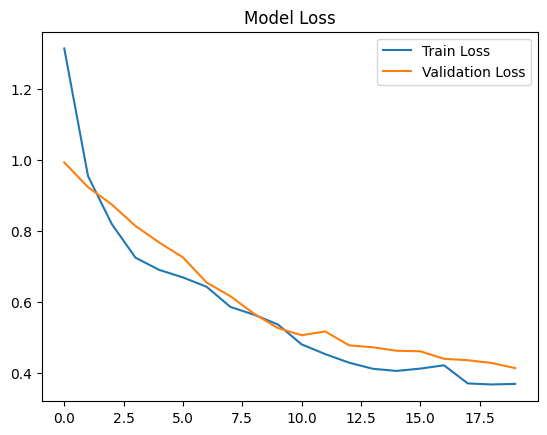

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.91      0.84        45
           1       0.88      0.80      0.84        45
           2       0.95      0.87      0.91        45

    accuracy                           0.86       135
   macro avg       0.87      0.86      0.86       135
weighted avg       0.87      0.86      0.86       135



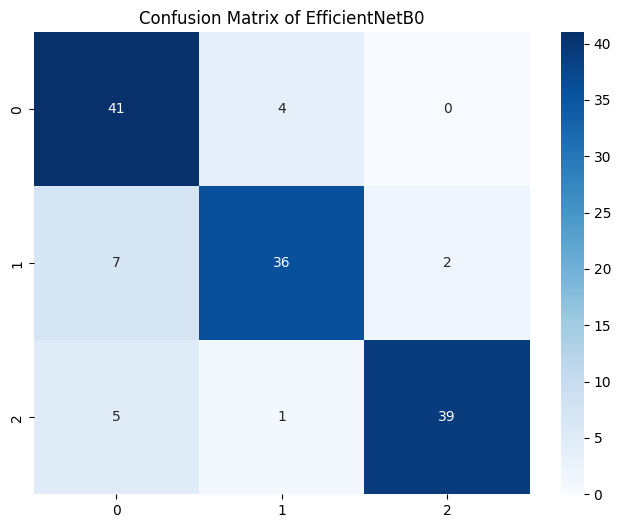

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# True labels from test generator
y_true = test_gen.classes

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1) #argmax finds the index of the largest value in an array

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title("Confusion Matrix of EfficientNetB0")
plt.show()